In [1]:
# My raw data files are imported from the 
# ...(data only for .csv download) pages in the google sheet.
# If you download them directly from that page and upload them
# to your jupyter notebook this code will work. If you do not
# there will likely be errors (the code will probably look at 
# the wrong column/row, etc...).

# IMPORTANT: my files are saved as the following
# plateau_1_raw.csv
# plateau_2_raw.csv
# background_raw_900v.csv
# radiation_raw_900v.csv
# muon_decay_data.xls

This code produces the following graphs:

r_vs_V_plateau_1.png

r_vs_V_plateau_2.png

r_vs_V_plateau_1_fit_ROI.png

r_vs_V_plateau_2_fit_ROI.png

background_with_poisson.png

counts_distribution_no_dt.png

counts_distribution_yes_dt.png

rate_distribution_yes_dt.png

precision_vs_data_quantity_NoLog.png

precision_vs_data_quantity_YesLog.png

raw_muon_fine.png

masked_muon_200bins.png

masked_muon_log_lin_YesBgnd.png

masked_muon_log_lin_NoBgd.png

MUON_CURVEFIT_fixedB2_overlay_residuals.png

MUON_tau_vs_background.png

MUON_redchi2_vs_background.png

MUON_fit_fixedB2_sigmaB_overlay_residuals.png

MUON_fit_3param_overlay_residuals.png

In [13]:
# import statements
import matplotlib.pyplot as plt
import numpy as np
from numpy import genfromtxt
from scipy.special import factorial
from scipy.stats import poisson, binomtest, norm
from scipy.optimize import curve_fit
from scipy.special import erf

import pandas as pd
import os

In [3]:
!pip install xlrd

In [4]:
# Verifying file names for data and kernel location. 
# Note that (this was my issue) a decayed kernel will always return a filenotfound error. Restart your kernel before trying to debug.

#os.chdir('nuclear decay')
#!pwd
#!ls

In [5]:
# csv imports to numpy

# plateau data
plateau_1 = genfromtxt('plateau_1_raw.csv', delimiter=',')
plateau_2 = genfromtxt('plateau_2_raw.csv', delimiter=',')

# background radiation data (900v, shelf 3)
background = genfromtxt('background_raw_900v.csv', delimiter=',')

# counting data (900v, shelf 3)
source = genfromtxt('radiation_raw_900v.csv', delimiter=',')

# muon decay data
df = pd.read_excel("muon_decay_data.xls", engine="xlrd")
muon = df.to_numpy()

#df.head(), muon.shape

Assumtions for estimation of error.

Because of the dial, I assume a $\pm 10 V$ error in the voltage measurement for each voltage data point.

Because of the analog reader, I assume a $\pm 0.05 s$ error in the start and end time measurments.

The counts $n$ per time interval are approximately Poisson and can be assumed to have an error of $\pm\sqrt{n}$.

Computing these errors.

Time errors add in quadrature since we are computing a difference. So

$\sigma_{\Delta t}=\sqrt{\sigma_{t_{i}}^2+\sigma_{t_{f}}^2}=\sqrt{0.05^2+0.05^2}=\sqrt{0.005}=\sqrt{\frac{1}{200}}$

is the error on our time measurement.

The error on the rate $r=\frac{n}{\Delta t}$ has that

$\sigma_{r}^2=\left(\frac{\partial r}{\partial n}\right)^2\sigma_{n}^2+\left(\frac{\partial r}{\partial \Delta t}\right)^2\sigma_{\Delta t}^2=\left(\frac{1}{\Delta t}\right)^2n + \left(\frac{n}{(\Delta t)^2}\right)\frac{1}{200}$

i.e.

$\sigma_{r}=\sqrt{\left(\frac{n}{(\Delta t)^2}\right)+\left(\frac{n}{200(\Delta t)^2}\right)}$
$=\frac{\sqrt{n}}{\Delta t}\sqrt{\frac{201}{200}}$

It should be noted that this is approx. proportional (time error is negligible). Regardless, it is not very difficult to implement computationally so I will keep it in the code formally.

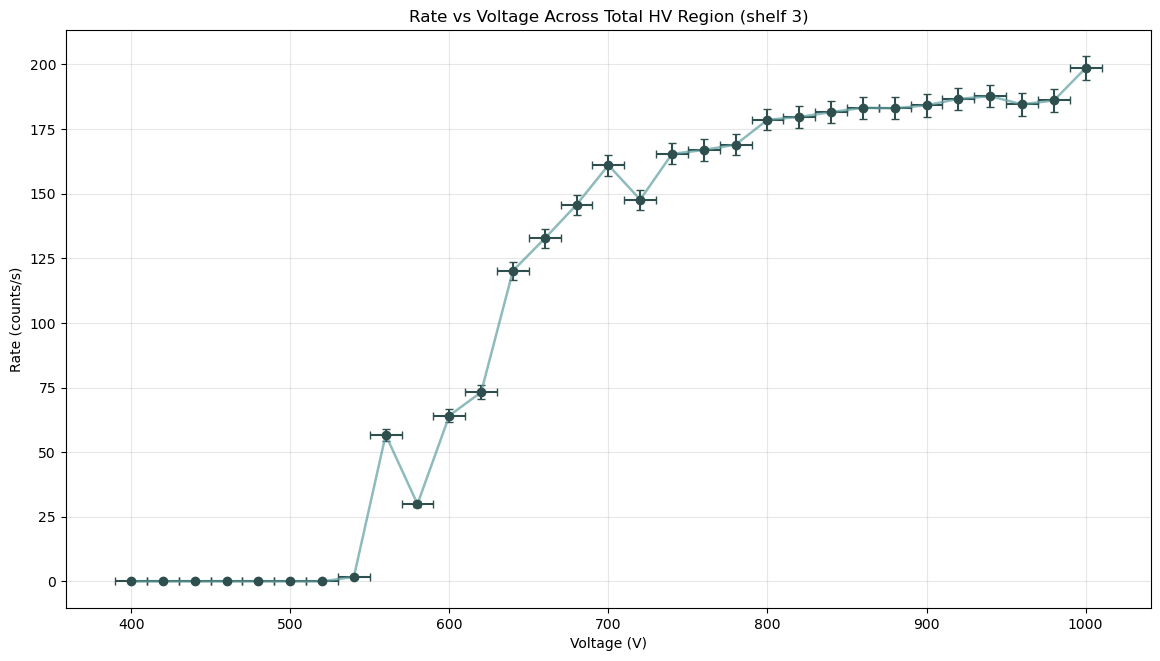

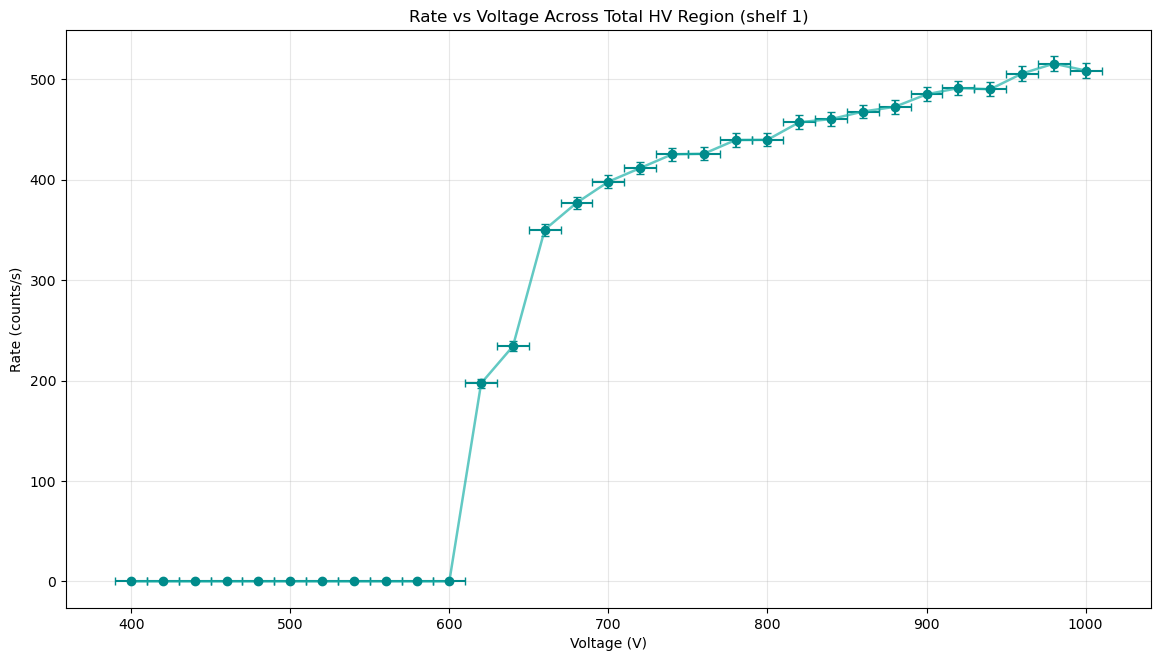

In [6]:
# plot and save scatterplot for plateau 1 and 2

# columns (starting at 0, i.e. 0-indexed):
# 0: V, 3: Δt, 4: n, 5: r
V1  = plateau_1[:, 0]
dt1 = plateau_1[:, 3]
n1  = plateau_1[:, 4]
r1  = plateau_1[:, 5]

V2  = plateau_2[:, 0]
dt2 = plateau_2[:, 3]
n2  = plateau_2[:, 4]
r2  = plateau_2[:, 5]

# uncertainties
sigma_V = 10.0  # volts


# automated propagation, if we change errors later
# time uncertainty (if you want the exact propagation form)
#sigma_ts = 0.05
#sigma_te = 0.05
#sigma_dt = np.sqrt(sigma_ts**2 + sigma_te**2)

#sigma_r1 = np.sqrt( (np.sqrt(n1)/dt1)**2 + ((n1 * sigma_dt)/(dt1**2))**2 )
#sigma_r2 = np.sqrt( (np.sqrt(n2)/dt2)**2 + ((n2 * sigma_dt)/(dt2**2))**2 )

# simplified factor from above (not automated propagation)
sigma_r1 = (np.sqrt(n1)/dt1) * np.sqrt(201/200)
sigma_r2 = (np.sqrt(n2)/dt2) * np.sqrt(201/200)

# PLOTTING-----------------------------------------------------------------------------------------

# ---plateau 1 (shelf 3)---
plt.figure(figsize=(14, 7.5))

# points & error bars
plt.errorbar(
    V1, r1,
    xerr=sigma_V,
    yerr=sigma_r1,
    fmt='o',
    color='darkslategrey',
    capsize=3
)

# connecting line
plt.plot(
    V1, r1,
    color='cadetblue',
    linewidth=1.8,
    alpha=0.7
)

plt.xlabel('Voltage (V)')
plt.ylabel('Rate (counts/s)')
plt.title('Rate vs Voltage Across Total HV Region (shelf 3)')
plt.grid(True, alpha=0.3)

plt.savefig('r_vs_V_plateau_1.png', dpi=300, bbox_inches='tight')
plt.show()

# ---plateau 2 (shelf 1)---
plt.figure(figsize=(14, 7.5))

# points & error bars
plt.errorbar(
    V2, r2,
    xerr=sigma_V,
    yerr=sigma_r2,
    fmt='o',
    color='darkcyan',
    capsize=3
)

# connecting line
plt.plot(
    V2, r2,
    color='lightseagreen',
    linewidth=1.8,
    alpha=0.7
)

plt.xlabel('Voltage (V)')
plt.ylabel('Rate (counts/s)')
plt.title('Rate vs Voltage Across Total HV Region (shelf 1)')
plt.grid(True, alpha=0.3)

plt.savefig('r_vs_V_plateau_2.png', dpi=300, bbox_inches='tight')
plt.show()



# Note that this will automatically save the pngs of these graphs to your working 
# jupyter notebook folder. If you don't want to do this, comment out the plt.savefig lines.

# dpi=300 is high-resolution (default in matplotlib is dpi=100 to save memory).

---- Plateau 1 (shelf 3) ----
ROI: V >= 700 V  (N=16)
Fit: r = mV + b
m = 0.121966 ± 0.011 counts/s/V
b = 73.9059 ± 9.7 counts/s
chi2/nu = 26.57/14 = 1.90
Plateau slope = 6.87 ± 0.64 % per 100 V (expected ~1–2)

---- Plateau 2 (shelf 1) ----
ROI: V >= 700 V  (N=16)
Fit: r = mV + b
m = 0.377957 ± 0.018 counts/s/V
b = 140.698 ± 16 counts/s
chi2/nu = 7.39/14 = 0.53
Plateau slope = 8.18 ± 0.40 % per 100 V (expected ~1–2)


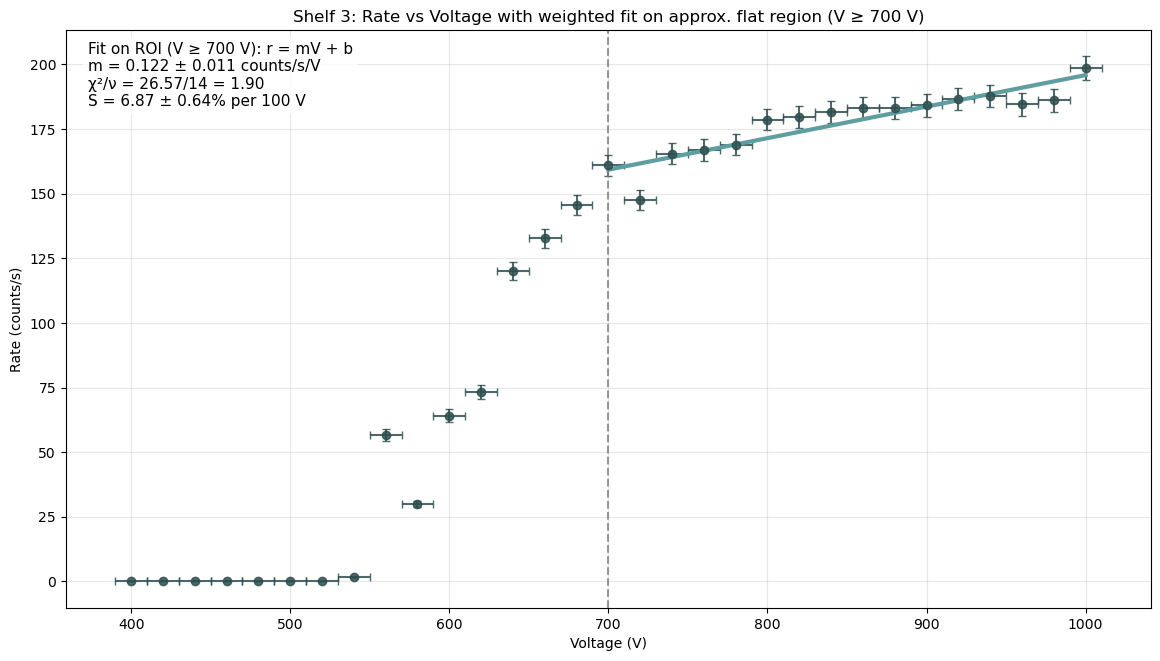

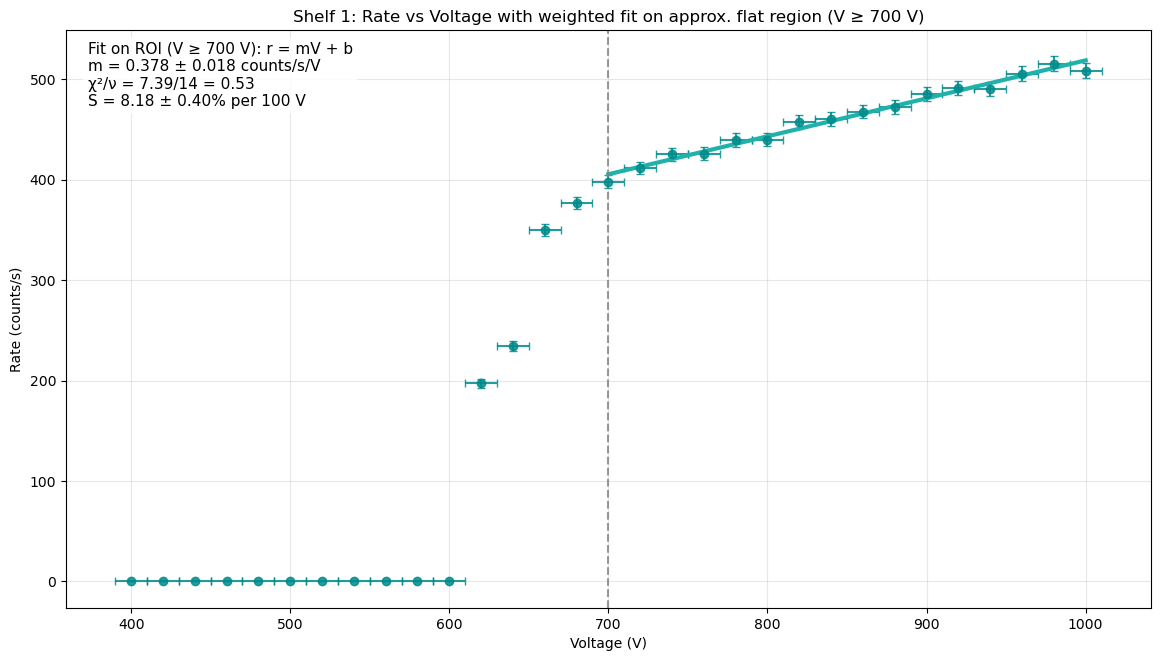

In [7]:
# chisq line fit for plateau region; plateaus 1 and 2

# NOTE: I take the start of the plateau region to be at 700V since this is the
# point where the data looks to be approximately flat. In practice, to find the halfway point, you 
# would actually want to take it to be somewhere at 650 (when it just begins to flatten out).
# The reason I do not fo that here is because I want to analyze if the slope has the expected
# 1-2% slope per 100V as anticipated (pg 330 in the textbook). This would serve as a good
# justification for our data,  but to get a good estimate of the slope in the flat region we should,
# of course, take only from data points that are approximately flat.

# note also that variable definitions for this code block are defined in the code block above

# --------------------------------------------------------------------------------------------------

# weighted linear fit (helper func)
def weighted_line_fit(V, r, sigma_r):
    
    # fit r = m V + b with weights 1/sigma_r^2.
    # returns m, b, sigma_m, sigma_b, chi2, dof, chi2_red.
    
    V = np.asarray(V)
    r = np.asarray(r)
    sigma_r = np.asarray(sigma_r)

    # design matrix
    X = np.column_stack([V, np.ones_like(V)])

    # weights
    w = 1.0 / (sigma_r**2)
    W = np.diag(w)

    # normal equations: beta = (X^T W X)^(-1) X^T W y
    XT_W = X.T @ W
    cov = np.linalg.inv(XT_W @ X)
    beta = cov @ (XT_W @ r)

    m, b = beta
    sigma_m = np.sqrt(cov[0, 0])
    sigma_b = np.sqrt(cov[1, 1])

    # chi-square
    r_fit = m * V + b
    chi2 = np.sum(((r - r_fit) / sigma_r) ** 2)
    dof = len(V) - 2
    chi2_red = chi2 / dof if dof > 0 else np.nan

    return m, b, sigma_m, sigma_b, chi2, dof, chi2_red

# plateau-slope (% per 100V) from the fit (helper func)
def plateau_slope_percent_per_100V(m, b, Vmin, Vmax):
    
   # plateau slope as FRACTIONAL increase per 100 V:
   #     S = (Δr / r_ref) * 100%   with Δr = 100*m
   # we take r_ref as the fitted rate at the midpoint of the ROI.
   # returns S, Vmid, r_ref.

    Vmid = 0.5 * (Vmin + Vmax)
    r_ref = m * Vmid + b
    S = (100.0 * m / r_ref) * 100.0  # (% per 100 V)
    return S, Vmid, r_ref

# --------------------------------------------------------------------------------------------------

# region of interest (flat plateau): V\geq 700V
V_cut = 700.0
mask1 = V1 >= V_cut
mask2 = V2 >= V_cut

V1p, r1p, s1p = V1[mask1], r1[mask1], sigma_r1[mask1]
V2p, r2p, s2p = V2[mask2], r2[mask2], sigma_r2[mask2]


# weighted chisq fits on ROI
m1, b1, sm1, sb1, chi21, dof1, chi2r1 = weighted_line_fit(V1p, r1p, s1p)
m2, b2, sm2, sb2, chi22, dof2, chi2r2 = weighted_line_fit(V2p, r2p, s2p)


# plateau slope (% per 100 V) from fit
V1min, V1max = V1p.min(), V1p.max()
V2min, V2max = V2p.min(), V2p.max()

S1, Vmid1, rref1 = plateau_slope_percent_per_100V(m1, b1, V1min, V1max)
S2, Vmid2, rref2 = plateau_slope_percent_per_100V(m2, b2, V2min, V2max)


# error propagation on S dominated by slope uncertainty
sigma_S1 = abs(S1) * (sm1 / abs(m1))
sigma_S2 = abs(S2) * (sm2 / abs(m2))

# ---------------------------------------------------------------------------------------------------

# print analysis summary 
print("---- Plateau 1 (shelf 3) ----")
print(f"ROI: V >= {V_cut:.0f} V  (N={len(V1p)})")
print(f"Fit: r = mV + b")
print(f"m = {m1:.6g} ± {sm1:.2g} counts/s/V")
print(f"b = {b1:.6g} ± {sb1:.2g} counts/s")
print(f"chi2/nu = {chi21:.2f}/{dof1} = {chi2r1:.2f}")
print(f"Plateau slope = {S1:.2f} ± {sigma_S1:.2f} % per 100 V (expected ~1–2)")

print("\n---- Plateau 2 (shelf 1) ----")
print(f"ROI: V >= {V_cut:.0f} V  (N={len(V2p)})")
print(f"Fit: r = mV + b")
print(f"m = {m2:.6g} ± {sm2:.2g} counts/s/V")
print(f"b = {b2:.6g} ± {sb2:.2g} counts/s")
print(f"chi2/nu = {chi22:.2f}/{dof2} = {chi2r2:.2f}")
print(f"Plateau slope = {S2:.2f} ± {sigma_S2:.2f} % per 100 V (expected ~1–2)")

# ---------------------------------------------------------------------------------------------------

# ---plot plateau 1 data & best-fit line on ROI---

# define line domain only on ROI
Vfit1 = np.linspace(V1min, V1max, 200)
rfit1 = m1 * Vfit1 + b1

plt.figure(figsize=(14, 7.5))

# points and errorbars in dataset
plt.errorbar(V1, r1, xerr=sigma_V, yerr=sigma_r1, fmt='o', color='darkslategrey', capsize=3, alpha=0.85)

# ROI best-fit line
plt.plot(Vfit1, rfit1, color='cadetblue', linewidth=3)

# mark ROI threshold
plt.axvline(V_cut, linestyle='--', linewidth=1.5, color='gray', alpha=0.8)

plt.xlabel('Voltage (V)')
plt.ylabel('Rate (counts/s)')
plt.title('Shelf 3: Rate vs Voltage with weighted fit on approx. flat region (V ≥ 700 V)')
plt.grid(True, alpha=0.3)

annot1 = (
    f"Fit on ROI (V ≥ {V_cut:.0f} V): r = mV + b\n"
    f"m = {m1:.3g} ± {sm1:.2g} counts/s/V\n"
    f"χ²/ν = {chi21:.2f}/{dof1} = {chi2r1:.2f}\n"
    f"S = {S1:.2f} ± {sigma_S1:.2f}% per 100 V"
)
plt.text(0.02, 0.98, annot1, transform=plt.gca().transAxes,
         va='top', ha='left', fontsize=11,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.85, edgecolor='none'))

plt.savefig('r_vs_V_plateau_1_fit_ROI.png', dpi=300, bbox_inches='tight')
plt.show()


# ---plot plateau 2 data & best-fit line on ROI---

Vfit2 = np.linspace(V2min, V2max, 200)
rfit2 = m2 * Vfit2 + b2

plt.figure(figsize=(14, 7.5))

plt.errorbar(V2, r2, xerr=sigma_V, yerr=sigma_r2, fmt='o', color='darkcyan', capsize=3, alpha=0.85)

plt.plot(Vfit2, rfit2, color='lightseagreen', linewidth=3)

plt.axvline(V_cut, linestyle='--', linewidth=1.5, color='grey', alpha=0.8)

plt.xlabel('Voltage (V)')
plt.ylabel('Rate (counts/s)')
plt.title('Shelf 1: Rate vs Voltage with weighted fit on approx. flat region (V ≥ 700 V)')
plt.grid(True, alpha=0.3)

annot2 = (
    f"Fit on ROI (V ≥ {V_cut:.0f} V): r = mV + b\n"
    f"m = {m2:.3g} ± {sm2:.2g} counts/s/V\n"
    f"χ²/ν = {chi22:.2f}/{dof2} = {chi2r2:.2f}\n"
    f"S = {S2:.2f} ± {sigma_S2:.2f}% per 100 V"
)
plt.text(0.02, 0.98, annot2, transform=plt.gca().transAxes,
         va='top', ha='left', fontsize=11,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.85, edgecolor='none'))

plt.savefig('r_vs_V_plateau_2_fit_ROI.png', dpi=300, bbox_inches='tight')
plt.show()

Since our data accounts for varying $\Delta t$, we assume that there is some true underlying rate $\lambda$.

For ant interval of duration $\Delta t$, the number of counts $N$ is distributed as

$P(N=n|\Delta t)=\frac{(\lambda\Delta t)^n e^{-\lambda\Delta t}}{n!}$

such that the Poisson mean is not a single $\bar{n}$ (as in the lab overview), but $\lambda\Delta t$, which varies slightly from trial to trial if $\Delta t$ varies.

Our spread of $\Delta t$ is fairly small, but since we have the tools to be exact we might as well do so.


We estimate the rate by

$\hat{\lambda}=\frac{\sum_{i}n_i}{\sum_{i}\Delta t_i}$

such that each trial has a predicted mean

$\mu_{i}=\hat{\lambda}\Delta t_i$.

In such a case, the probability that a randomly selected trial has $n$ counts is an average of Poisson distributions:

$P_{\text{predicted}}(n)=\frac{1}{N_{\text{trials}}}\sum_{i=1}^{N_{\text{}trials}}\frac{\mu_{i}^{n}e^{-\mu_i}}{n!}$.


Also, for the data I use a exact central 95% Poisson prediction interval for $N_i$ ~ $\text{Pois}(\hat{\lambda}\Delta t_i)$, rather than the $2\sigma$ measurement. This is because the $2\sigma$ measurement can be skewed by small $n$ (as is the case here). That is, for each trial $i$, I compute integer bounds $L_i,U_i$ such that

$P(N\leq L_i | \mu_i)\approx 0.025$

$P(N\leq U_i | \mu_i)\approx 0.975$

and check if $n_i\in[L_i,U_i]$. If the Poisson model is accurate, then about 95% of trials should land inside their interval.
Note, however, that for our 50 trials this will give an approxmate standard error SE of

$\text{SE}\approx \sqrt{\frac{0.95\cdot 0.05}{50}}=\sqrt{0.00095}\approx 0.0308$

so a trypical 95% error range for an observed coverage fraction is roughly

$0.95\pm 2(0.0308)\approx 0.95\pm 0.06$

i.e. about 89%-100%.

Estimated rate λ = 0.3558576569372251 counts per second


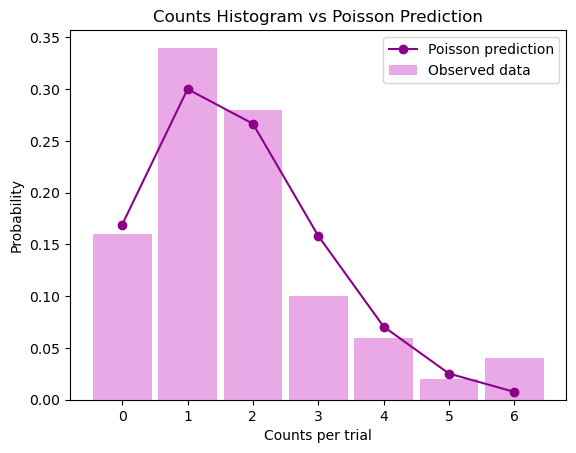

Coverage fraction inside predicted 95% Poisson interval = 0.96
Inside count = 48 out of 50


In [8]:
# background data

# --- extract Δt and counts ---
dt_b = background[:,3]       # column 4: Δt
counts_b = background[:,4]   # column 5: counts
Ntrials = len(counts_b)


# --- estimate true rate \lambda ---
lambda_b = counts_b.sum() / dt_b.sum() # technically this is \hat{\lambda}
print("Estimated rate λ =", lambda_b, "counts per second")


# --- build histogram of observed counts ---
n_max = int(counts_b.max())
bins = np.arange(-0.5, n_max+1.5, 1)
hist, edges = np.histogram(counts_b, bins=bins, density=True)
n_vals = np.arange(0, n_max+1)


# --- compute predicted mixture Poisson distribution ---
mu = lambda_b * dt_b   # mean for each trial
P_pred = np.zeros_like(n_vals, dtype=float)

for i,n in enumerate(n_vals):
    P_pred[i] = np.mean((mu**n)*np.exp(-mu)/factorial(n))


# --- plot histogram & prediction overlay ---
plt.figure()
plt.bar(n_vals, hist, width=0.9, alpha=0.6, label="Observed data", color='orchid')
plt.plot(n_vals, P_pred, 'o-', label="Poisson prediction", color='darkmagenta')

plt.xlabel("Counts per trial")
plt.ylabel("Probability")
plt.legend()
plt.title("Counts Histogram vs Poisson Prediction")

plt.savefig('background_with_poisson.png', dpi=300, bbox_inches='tight')
plt.show()


# --- 95% coverage check using exact Poisson prediction intervals ---
counts_int = counts_b.astype(int)
alpha = 0.05  # central 95% interval

L = poisson.ppf(alpha/2, mu).astype(int)         # lower 2.5% quantile per trial
U = poisson.ppf(1 - alpha/2, mu).astype(int)     # upper 97.5% quantile per trial

inside = (counts_int >= L) & (counts_int <= U)
coverage = inside.mean()

print("Coverage fraction inside predicted 95% Poisson interval =", coverage)
print("Inside count =", inside.sum(), "out of", Ntrials)

For the Cs-137 source (below), I will similarly use a Gaussian mixture to account for our varying $\Delta t$.

In such a case,

$N_i$ ~ $\text{Poisson}(\lambda_s\Delta t_i)\approx \text{Gaussian}(\mu_i,\sigma_i^2)$

for $\mu_i=\lambda_s\Delta t_i$, $\sigma_i=\sqrt{\mu_i}$.

Total rate λ_total = 185.196 counts/sec
Source-only rate λ_source = 184.84014234306278 counts/sec


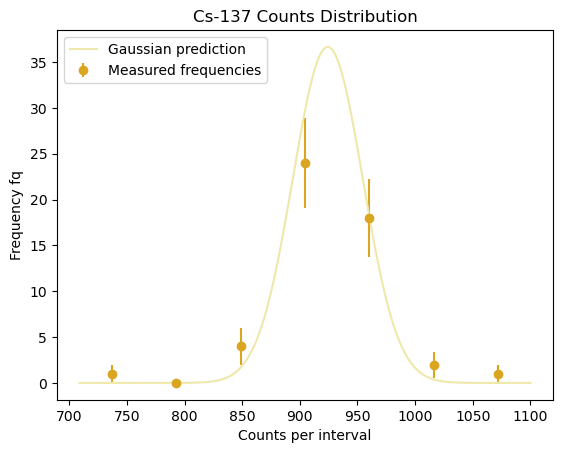

Mean source count rate = 185.19409617598632 counts/sec
Error on mean = 0.8684508644160314 counts/sec


In [9]:
# counts data

# --- source + background ---
dt_s = source[:,3]
counts_s = source[:,4]
Ntrials = len(counts_s)

lambda_total = counts_s.sum() / dt_s.sum()
print("Total rate λ_total =", lambda_total, "counts/sec")


# --- source-alone rate ---
lambda_source = lambda_total - lambda_b
print("Source-only rate λ_source =", lambda_source, "counts/sec")


# --- histogram ---
n_min = counts_s.min()
n_max = counts_s.max()

nbins = 7
bins = np.linspace(n_min, n_max, nbins+1)

freq, edges = np.histogram(counts_s, bins=bins)
bin_centers = 0.5*(edges[1:] + edges[:-1])

# frequency uncertainties
freq_err = np.sqrt(freq)

# predicted mean counts per trial = λ_source * average Δt
dt_mean = dt_s.mean()
mu = lambda_source * dt_mean
sigma = np.sqrt(mu)

x_plot = np.linspace(n_min, n_max, 400)
prediction = Ntrials * norm.pdf(x_plot, mu, sigma) * (edges[1]-edges[0])

# plot freq vs nq with error bars and prediction curve
plt.figure()
plt.errorbar(bin_centers, freq, yerr=freq_err, fmt='o', label="Measured frequencies", color='goldenrod')
plt.plot(x_plot, prediction, label="Gaussian prediction", color='palegoldenrod')
plt.xlabel("Counts per interval")
plt.ylabel("Frequency fq")
plt.title("Cs-137 Counts Distribution")
plt.legend()

plt.savefig('counts_distribution_no_dt.png', dpi=300, bbox_inches='tight')
plt.show()


# --- mean count rate and error on the mean ---
rate_trials = counts_s / dt_s
mean_rate = rate_trials.mean()
std_rate = rate_trials.std(ddof=1)
error_on_mean = std_rate / np.sqrt(Ntrials)

print("Mean source count rate =", mean_rate, "counts/sec")
print("Error on mean =", error_on_mean, "counts/sec")

Total rate λ_total = 185.196 counts/sec
Source-only rate λ_source = 184.84014234306278 counts/sec

--- Rate uncertainties (Poisson propagation) ---
sigma(lambda_total)  = 0.860688 counts/s
sigma(lambda_b)      = 0.0377208 counts/s
sigma(lambda_source) = 0.861514 counts/s

--- Within-band probabilities (trial-by-trial Gaussian approx) ---
Empirical P(|Z|<=1) = 0.70000 ± 0.07686   (Gaussian: 0.68269)
Empirical P(|Z|<=2) = 0.94000 ± 0.03569   (Gaussian: 0.95450)

(Components of the ± uncertainty)
  Binomial SE(|Z|<=1): 0.06481   Lambda-prop SE: 0.04132
  Binomial SE(|Z|<=2): 0.03359   Lambda-prop SE: 0.01208


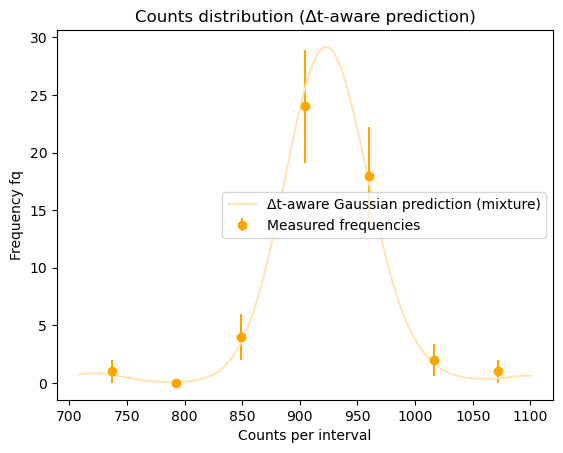

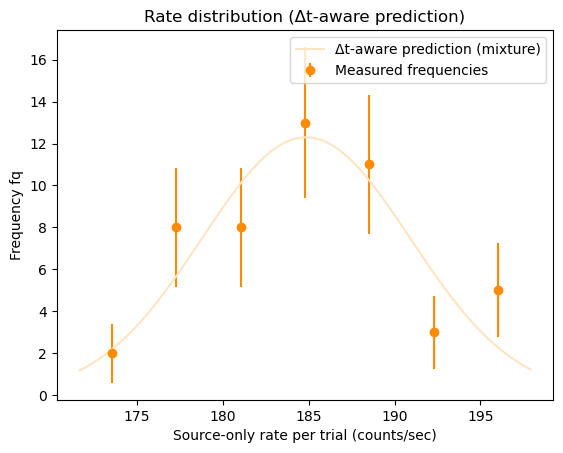

Mean source count rate (Cs only) = 184.83823851904907 counts/sec
Error on mean = 0.8684508644160313 counts/sec


In [14]:
# --- source & background ---
dt_s = source[:,3]
counts_s = source[:,4]
Ntrials = len(counts_s)

lambda_total = counts_s.sum() / dt_s.sum()
print("Total rate λ_total =", lambda_total, "counts/sec")

# --- source-alone rate ---
lambda_source = lambda_total - lambda_b
print("Source-only rate λ_source =", lambda_source, "counts/sec")

# ============================
# Prob(within 1σ, 2σ) with error propagation
# ============================

# --- Poisson-based uncertainties on rates ---
# For lambda = (sum counts)/(sum dt), with Poisson counts:
# Var(sum counts) = sum counts, so sigma_lambda = sqrt(sum counts)/(sum dt)
S_counts_s = counts_s.sum()
S_dt_s     = dt_s.sum()
sigma_lambda_total = np.sqrt(S_counts_s) / S_dt_s

S_counts_b = counts_b.sum()
S_dt_b     = dt_b.sum()
sigma_lambda_b = np.sqrt(S_counts_b) / S_dt_b

# assume independent background and source runs
sigma_lambda_source = np.sqrt(sigma_lambda_total**2 + sigma_lambda_b**2)

print("\n--- Rate uncertainties (Poisson propagation) ---")
print(f"sigma(lambda_total)  = {sigma_lambda_total:.6g} counts/s")
print(f"sigma(lambda_b)      = {sigma_lambda_b:.6g} counts/s")
print(f"sigma(lambda_source) = {sigma_lambda_source:.6g} counts/s")

# --- trial-by-trial Gaussian approximation ---
# predicted mean per trial (source-only) and corresponding sigma:
mu_i = lambda_source * dt_s
sigma_i = np.sqrt(mu_i)

# avoid any pathological cases if mu_i ~ 0
mask = mu_i > 0
counts_use = counts_s[mask]
mu_use     = mu_i[mask]
sig_use    = sigma_i[mask]
N_use      = len(counts_use)

z = (counts_use - mu_use) / sig_use
p1_emp = np.mean(np.abs(z) <= 1.0)
p2_emp = np.mean(np.abs(z) <= 2.0)

# binomial sampling uncertainty on the measured fraction (from finite N)
se1_bin = np.sqrt(p1_emp * (1 - p1_emp) / N_use)
se2_bin = np.sqrt(p2_emp * (1 - p2_emp) / N_use)

# --- propagate lambda_source uncertainty into p via Monte Carlo ---
# We resample lambda_source ~ Normal(lambda_source, sigma_lambda_source),
# recompute z, then recompute the fraction-in-band each time.
rng = np.random.default_rng(0)
Nsamp = 20000

lam_samps = rng.normal(loc=lambda_source, scale=sigma_lambda_source, size=Nsamp)
# enforce physical positivity (optional but sensible)
lam_samps = np.clip(lam_samps, 1e-12, None)

p1_samps = np.empty(Nsamp)
p2_samps = np.empty(Nsamp)

for k, lam in enumerate(lam_samps):
    mu_k = lam * dt_s[mask]
    sig_k = np.sqrt(mu_k)
    z_k = (counts_s[mask] - mu_k) / sig_k
    p1_samps[k] = np.mean(np.abs(z_k) <= 1.0)
    p2_samps[k] = np.mean(np.abs(z_k) <= 2.0)

# uncertainty due to propagated lambda_source uncertainty:
se1_lam = p1_samps.std(ddof=1)
se2_lam = p2_samps.std(ddof=1)

# combine (binomial counting noise) and (lambda uncertainty) in quadrature
se1_tot = np.sqrt(se1_bin**2 + se1_lam**2)
se2_tot = np.sqrt(se2_bin**2 + se2_lam**2)

# --- Gaussian prediction (standard normal) ---
p1_gauss = erf(1/np.sqrt(2))      # ≈ 0.682689...
p2_gauss = erf(2/np.sqrt(2))      # ≈ 0.954499...

print("\n--- Within-band probabilities (trial-by-trial Gaussian approx) ---")
print(f"Empirical P(|Z|<=1) = {p1_emp:.5f} ± {se1_tot:.5f}   (Gaussian: {p1_gauss:.5f})")
print(f"Empirical P(|Z|<=2) = {p2_emp:.5f} ± {se2_tot:.5f}   (Gaussian: {p2_gauss:.5f})")

print("\n(Components of the ± uncertainty)")
print(f"  Binomial SE(|Z|<=1): {se1_bin:.5f}   Lambda-prop SE: {se1_lam:.5f}")
print(f"  Binomial SE(|Z|<=2): {se2_bin:.5f}   Lambda-prop SE: {se2_lam:.5f}")


# ============================================================
# COUNTS histogram with Δt-aware mixture-Gaussian prediction
# ============================================================

# --- histogram (counts) ---
n_min = counts_s.min()
n_max = counts_s.max()

nbins = 7
bins = np.linspace(n_min, n_max, nbins + 1)

freq, edges = np.histogram(counts_s, bins=bins)
bin_centers = 0.5 * (edges[1:] + edges[:-1])
freq_err = np.sqrt(freq)  # 1-sigma error bars in frequency

# --- Δt-aware mixture-of-Gaussians prediction in COUNTS space ---
# per trial: N_i ~ Gaussian(mu_i, sigma_i^2) with mu_i = λ_source * Δt_i, sigma_i^2 = mu_i
mu_i = lambda_source * dt_s
sigma_i = np.sqrt(mu_i)

x_plot = np.linspace(n_min, n_max, 600)

# mixture pdf: average of per-trial normal pdfs evaluated at x_plot
pdf_mix = np.mean(
    (1.0 / (sigma_i[:, None] * np.sqrt(2*np.pi))) *
    np.exp(-0.5 * ((x_plot[None, :] - mu_i[:, None]) / sigma_i[:, None])**2),
    axis=0
)

# convert density -> expected frequency per bin (so it overlays fq vs nq)
bin_width = edges[1] - edges[0]
prediction_counts = Ntrials * pdf_mix * bin_width

# --- plot (counts) ---
plt.figure()
plt.errorbar(bin_centers, freq, yerr=freq_err, fmt='o', label="Measured frequencies", color='orange')
plt.plot(x_plot, prediction_counts, label="Δt-aware Gaussian prediction (mixture)", color='moccasin')
plt.xlabel("Counts per interval")
plt.ylabel("Frequency fq")
plt.title("Counts distribution (Δt-aware prediction)")
plt.legend()

plt.savefig('counts_distribution_yes_dt.png', dpi=300, bbox_inches='tight')
plt.show()


# ============================================================
# RATE histogram with Δt-aware mixture-Gaussian prediction
# ============================================================

# --- source-only rate per trial ---
rate_trials_source = (counts_s / dt_s) - lambda_b

# --- histogram (rate) ---
r_min = rate_trials_source.min()
r_max = rate_trials_source.max()

nbins_r = 7
bins_r = np.linspace(r_min, r_max, nbins_r + 1)

freq_r, edges_r = np.histogram(rate_trials_source, bins=bins_r)
bin_centers_r = 0.5 * (edges_r[1:] + edges_r[:-1])
freq_r_err = np.sqrt(freq_r)

# --- Δt-aware prediction in RATE space ---
# counts fluctuate as Poisson with mean (λ_total * Δt), so for rate = N/Δt:
# Var(N/Δt) = Var(N)/Δt^2 = (λ_total * Δt)/Δt^2 = λ_total/Δt
# Subtracting λ_b is just a shift, doesn't change variance.
mu_r_i = lambda_source * np.ones_like(dt_s)                # mean source rate (same for all trials)
sigma_r_i = np.sqrt(lambda_total / dt_s)                   # per-trial rate std dev

x_plot_r = np.linspace(r_min, r_max, 600)

pdf_mix_r = np.mean(
    (1.0 / (sigma_r_i[:, None] * np.sqrt(2*np.pi))) *
    np.exp(-0.5 * ((x_plot_r[None, :] - mu_r_i[:, None]) / sigma_r_i[:, None])**2),
    axis=0
)

bin_width_r = edges_r[1] - edges_r[0]
prediction_rate = Ntrials * pdf_mix_r * bin_width_r

# --- plot (rate) ---
plt.figure()
plt.errorbar(bin_centers_r, freq_r, yerr=freq_r_err, fmt='o', label="Measured frequencies", color='darkorange')
plt.plot(x_plot_r, prediction_rate, label="Δt-aware prediction (mixture)", color='bisque')
plt.xlabel("Source-only rate per trial (counts/sec)")
plt.ylabel("Frequency fq")
plt.title("Rate distribution (Δt-aware prediction)")
plt.legend()

plt.savefig('rate_distribution_yes_dt.png', dpi=300, bbox_inches='tight')
plt.show()


# ============================================================
# mean source count rate and error on the mean (source-only)
# ============================================================

mean_rate = rate_trials_source.mean()
std_rate = rate_trials_source.std(ddof=1)
error_on_mean = std_rate / np.sqrt(Ntrials)

print("Mean source count rate (Cs only) =", mean_rate, "counts/sec")
print("Error on mean =", error_on_mean, "counts/sec")

Fit: SEM(N) ≈ A / sqrt(N),  A = 6.0323535900553145
Log-log slope = -0.4890228335584036 (expected ≈ -0.5)


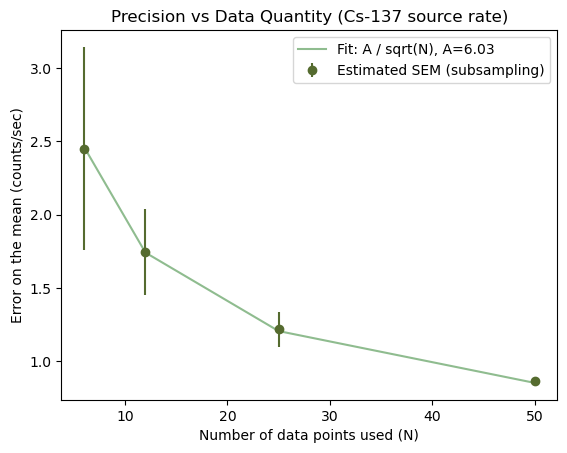

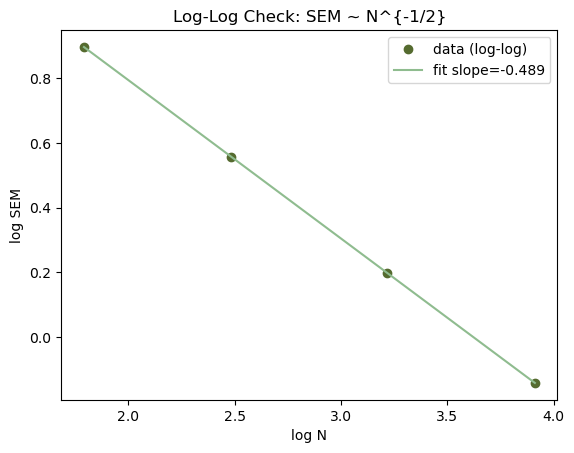

In [11]:
# precision as a function of data quantity

# --- build per-trial source-only rates (counts/sec) ---
dt_s = source[:,3]
counts_s = source[:,4]
Ntotal = len(counts_s)

rate_source = (counts_s / dt_s) - lambda_b


# --- choose data quantities: 1/8, 1/4, 1/2, full ---
fractions = np.array([1/8, 1/4, 1/2, 1.0])
Ns = np.maximum(2, (fractions * Ntotal).astype(int))  # at least 2 points


# --- estimate SEM for each N via repeated random subsampling ---
n_reps = 500  # increase if I want smoother points

sem_mean = []
sem_std  = []

rng = np.random.default_rng(0)

for N in Ns:
    sem_reps = []
    for _ in range(n_reps):
        idx = rng.choice(Ntotal, size=N, replace=False)
        sample = rate_source[idx]
        s = sample.std(ddof=1)
        sem_reps.append(s / np.sqrt(N))
    sem_reps = np.array(sem_reps)
    sem_mean.append(sem_reps.mean())
    sem_std.append(sem_reps.std(ddof=1))

sem_mean = np.array(sem_mean)
sem_std  = np.array(sem_std)


# --- fit to SEM(N) = A / sqrt(N) ---
x = 1 / np.sqrt(Ns)
A_fit = np.sum(x * sem_mean) / np.sum(x * x)   # least squares with intercept forced to 0
sem_fit = A_fit / np.sqrt(Ns)

print("Fit: SEM(N) ≈ A / sqrt(N),  A =", A_fit)

# --- log-log slope check (should be ~ -0.5) ---
logN = np.log(Ns)
logSEM = np.log(sem_mean)
slope, intercept = np.polyfit(logN, logSEM, 1)
print("Log-log slope =", slope, "(expected ≈ -0.5)")

# --- plot SEM vs N with fit (regular plot) ---
plt.figure()
plt.errorbar(Ns, sem_mean, yerr=sem_std, fmt='o', label="Estimated SEM (subsampling)", color='darkolivegreen')
plt.plot(Ns, sem_fit, '-',
         label=f"Fit: A / sqrt(N), A={A_fit:.3g}", color='darkseagreen')
plt.xlabel("Number of data points used (N)")
plt.ylabel("Error on the mean (counts/sec)")
plt.title("Precision vs Data Quantity (Cs-137 source rate)")
plt.legend()

plt.savefig('precision_vs_data_quantity_NoLog.png', dpi=300, bbox_inches='tight')
plt.show()

# --- plot SEM vs N with fit (log-log) ---
plt.figure()
plt.plot(np.log(Ns), np.log(sem_mean), 'o', label="data (log-log)", color='darkolivegreen')
plt.plot(np.log(Ns), intercept + slope*np.log(Ns), '-', label=f"fit slope={slope:.3f}", color='darkseagreen')
plt.xlabel("log N")
plt.ylabel("log SEM")
plt.title("Log-Log Check: SEM ~ N^{-1/2}")
plt.legend()

plt.savefig('precision_vs_data_quantity_YesLog.png', dpi=300, bbox_inches='tight')
plt.show()

For the muon lifetime data (below) I use (per bin)

raw data error bars:
$\sigma_N =\sqrt{N}$

log plot error bars:
$\sigma_{\text{log}(N)}=\frac{\sigma_{N}}{N}=\frac{\sqrt{N}}{N}$

background subtracted log plot:
$\sigma_{\text{bgnd}}=\frac{\sqrt{N}}{(N-b)}$

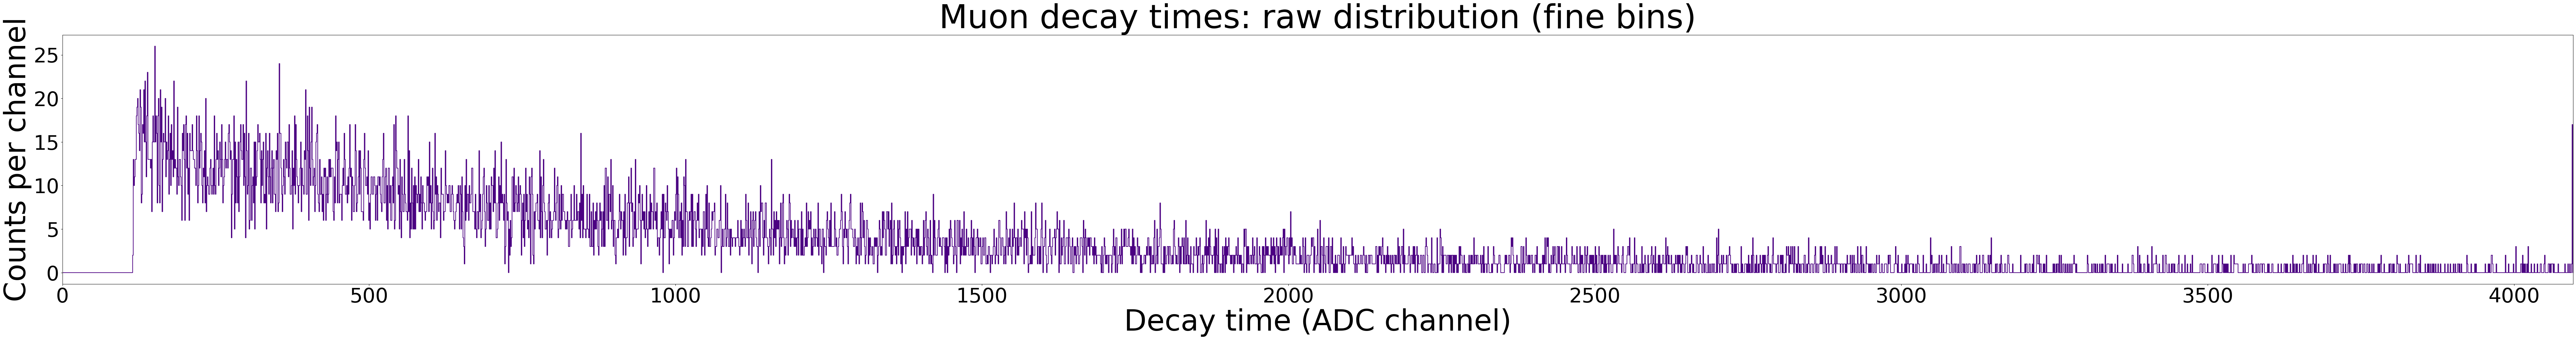

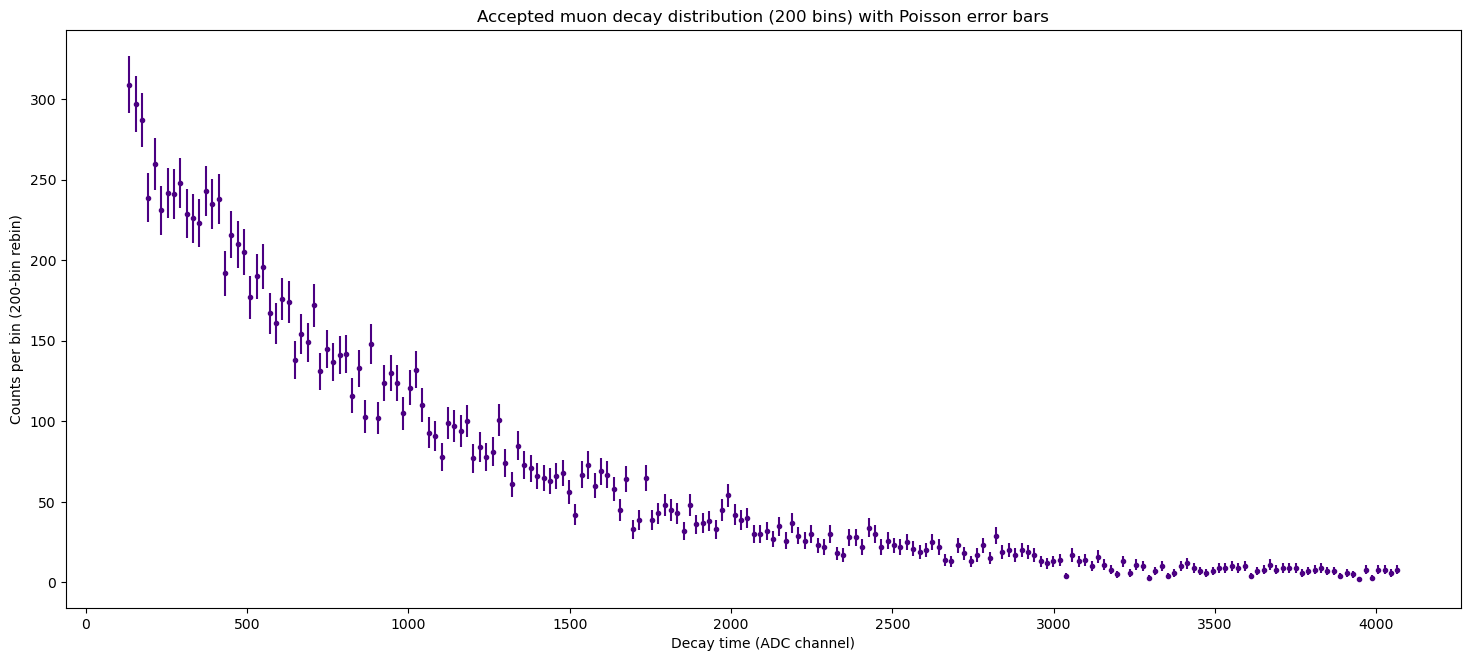

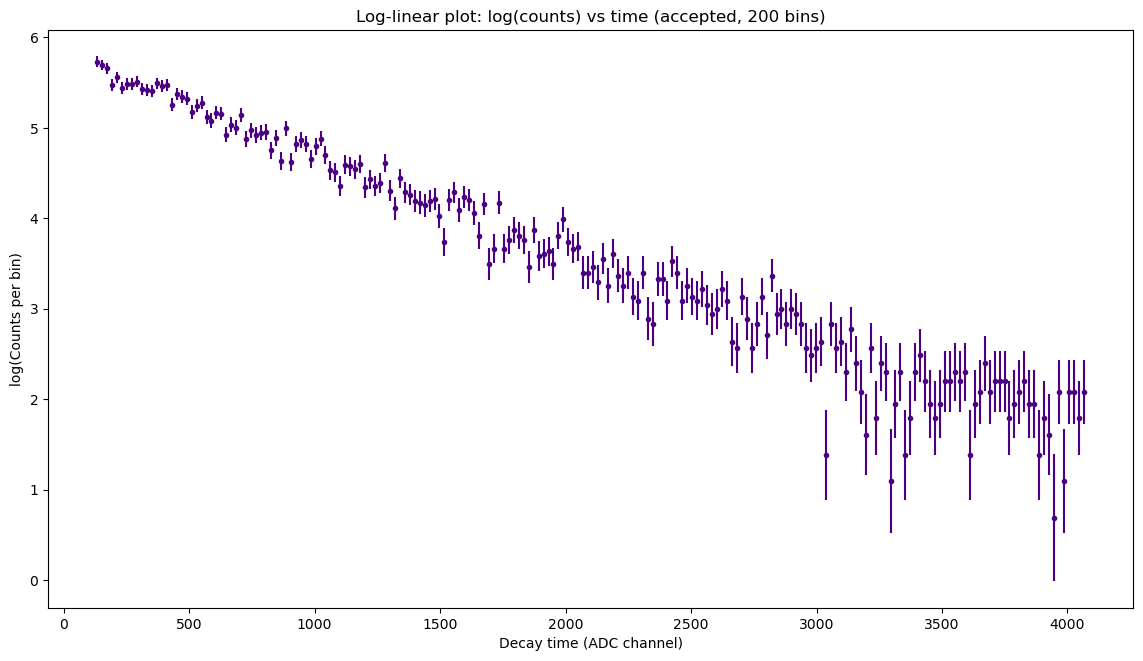

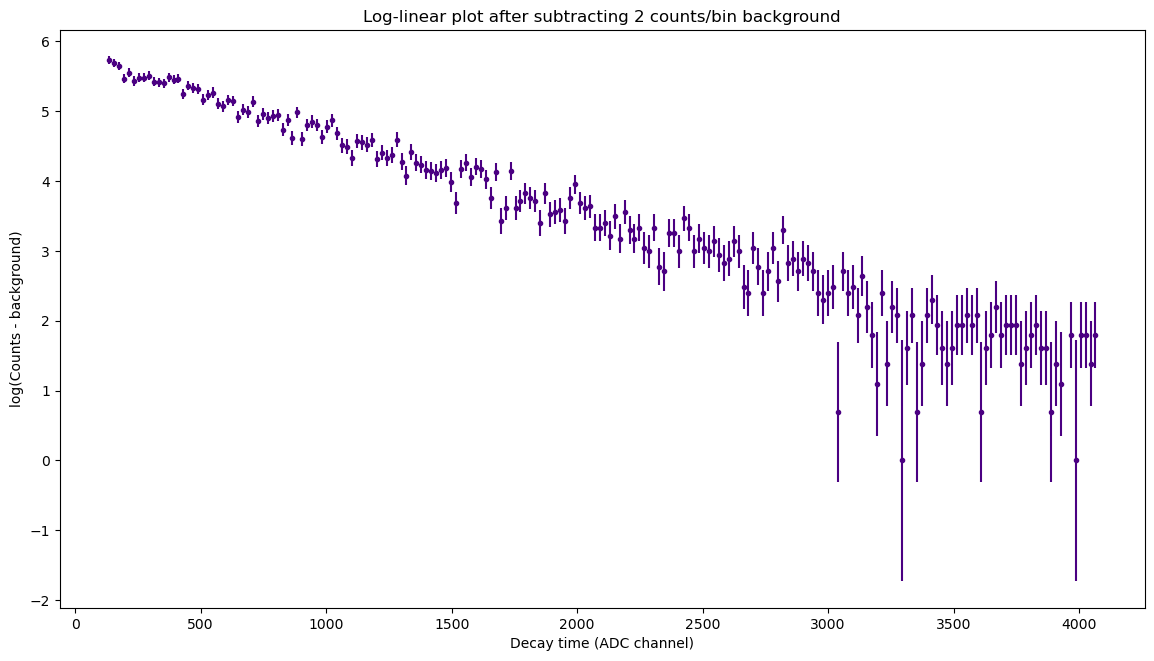

=== Fixed background fit (B=2) V2 ===
A = 336.3937154889249 +/- 4.876048526032591
tau = 2.1131391468367497 +/- 0.022583719409321617 microseconds (1-sigma)
tau 95% CI: 2.1131391468367497 +/- 0.04426409004227037 microseconds
chi^2 = 253.56165993374208 dof = 197 reduced chi^2 = 1.2871150250443761
Expected chi^2 ~ dof +/- sqrt(2*dof) = 197 +/- 19.849433241279208


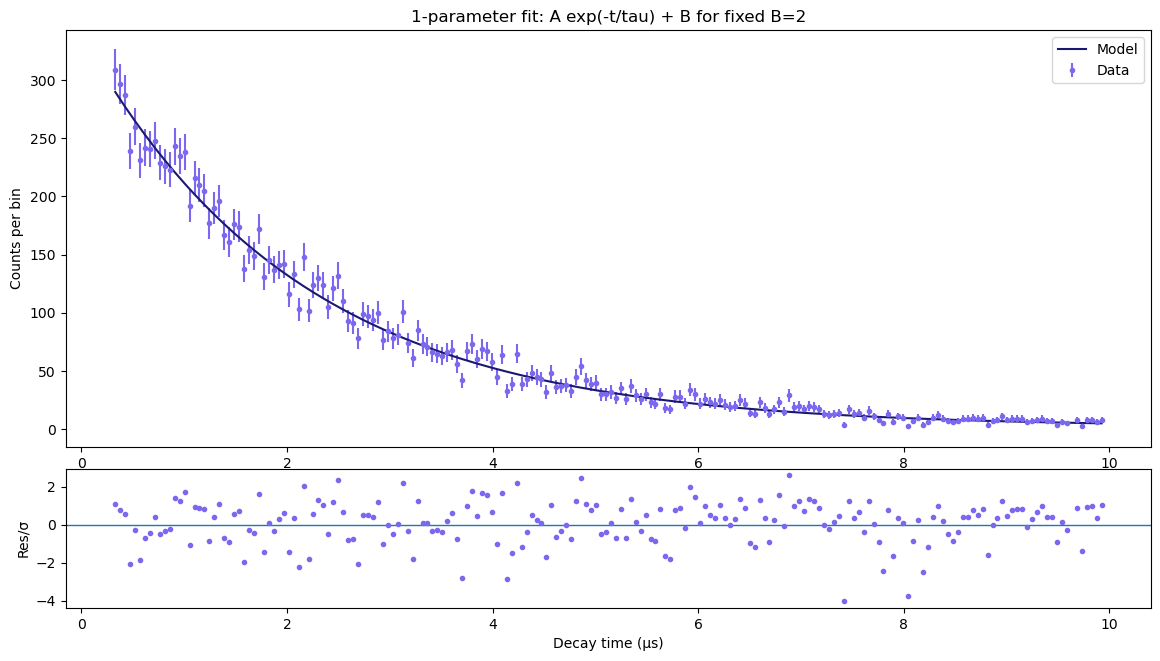

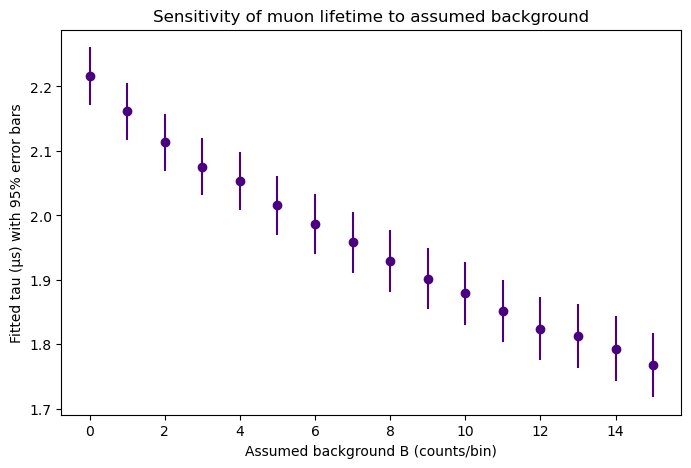

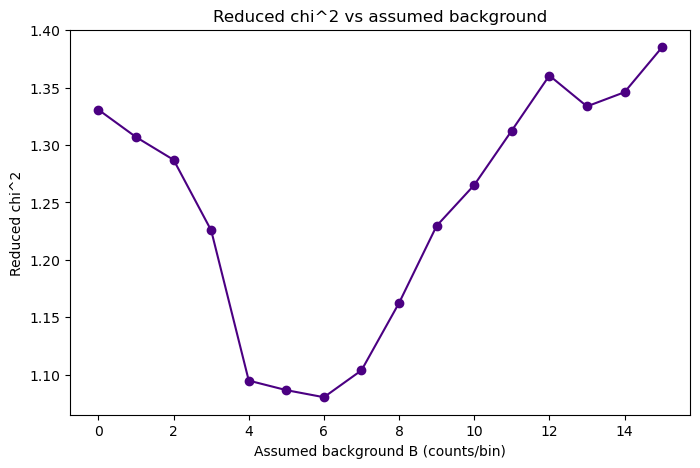

=== Fixed B=2 with sigma_B=0.6 propagated ===
tau = 2.1163843925843318 +/- 0.022838333131637592 microseconds (1-sigma)
tau 95% CI: 2.1163843925843318 +/- 0.04476313293800968 microseconds


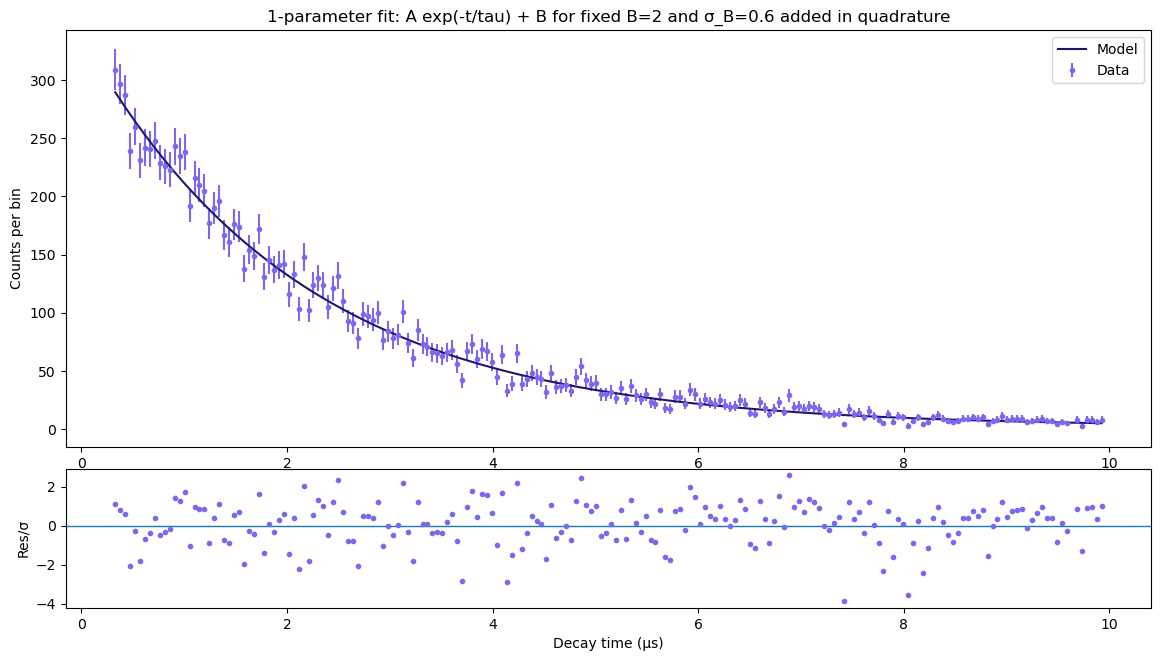

=== 3-parameter fit (A, tau, B) ===
tau = 2.142613811433015 +/- 0.038563844831887434 microseconds (1-sigma)
tau 95% CI: 2.142613811433015 +/- 0.07558513587049936 microseconds
B = 1.3483908367931876 +/- 0.5840554932808928 counts/bin
chi^2 = 258.4282800715995 dof = 197 reduced chi^2 = 1.3118186805664949


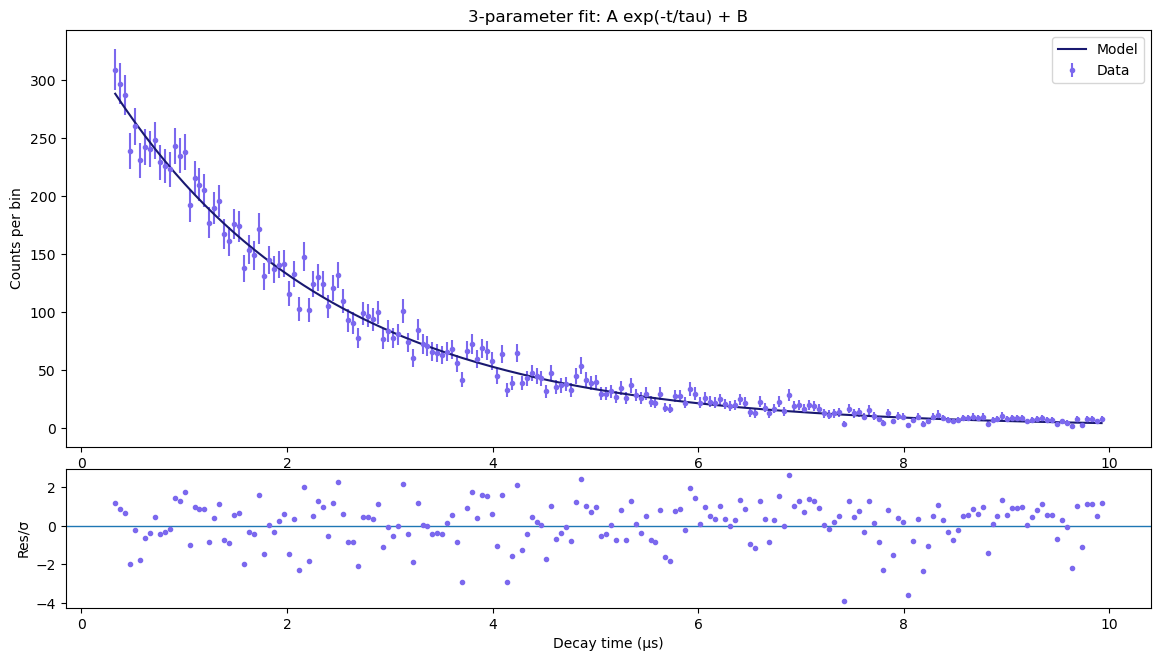

Systematic (2% time calibration) uncertainty in tau: 0.0428522762286603 microseconds

MUON MODEL COMPARISON (consistent fields across models)
Each model reports: tau (1σ), tau (95%), chi^2, dof, reduced chi^2, tau_sys(2%)

[Fixed background B=2 (V2)]
tau (1σ): 2.113 ± 0.02258
tau (95%): 2.113 ± 0.04426 (95%)
chi^2 = 253.562, dof = 197, reduced chi^2 = 1.287
B: 2 (fixed)
tau_sys (2%): 0.04226 μs

[Fixed B=2 with σ_B=0.6 (quadrature)]
tau (1σ): 2.116 ± 0.02284
tau (95%): 2.116 ± 0.04476 (95%)
chi^2 = 246.969, dof = 197, reduced chi^2 = 1.254
B: 2 (fixed)
σ_B: 0.6 counts/bin
tau_sys (2%): 0.04233 μs

[3-parameter fit (A, tau, B floating)]
tau (1σ): 2.143 ± 0.03856
tau (95%): 2.143 ± 0.07559 (95%)
chi^2 = 258.428, dof = 197, reduced chi^2 = 1.312
B (fit): 1.348 ± 0.5841
tau_sys (2%): 0.04285 μs

[Best-from-scan model (B chosen by reduced chi^2≈1)]
tau (1σ): 1.987 ± 0.02373
tau (95%): 1.987 ± 0.04651 (95%)
chi^2 = 197.695, dof = 183, reduced chi^2 = 1.080
B (chosen): 6
tau_sys (2%): 0.03973

In [12]:
# muon lifetime

# ============================
# HELPERS
# ============================

def exp_plus_bkg(t, A, tau, B):
    return A * np.exp(-t / tau) + B

def chisq(y, y_model, sigma):
    return np.sum(((y - y_model) / sigma)**2)

def plot_fit_with_residuals(t, y, sigma, y_model, title, fname=None):
    """
    two-panel plot:
      top: data with error bars + model curve
      bottom: normalized residuals (y - model)/sigma
    """
    resid = (y - y_model) / sigma

    fig = plt.figure(figsize=(14, 7.5))
    gs = fig.add_gridspec(2, 1, height_ratios=[3, 1], hspace=0.08)

    ax1 = fig.add_subplot(gs[0])
    ax1.errorbar(t, y, yerr=sigma, fmt='o', markersize=3, label="Data", color='mediumslateblue')
    # smooth model
    t_smooth = np.linspace(t.min(), t.max(), 600)
    # if y_model passed is on t grid, generate smooth using interpolation assumption is not safe;
    # caller should pass a callable model if needed. Here we just plot line through provided points:
    ax1.plot(t, y_model, '-', label="Model", color='midnightblue')
    ax1.set_ylabel("Counts per bin")
    ax1.set_title(title)
    ax1.legend()

    ax2 = fig.add_subplot(gs[1], sharex=ax1)
    ax2.axhline(0, linewidth=1)
    ax2.plot(t, resid, 'o', markersize=3, color='mediumslateblue')
    ax2.set_xlabel("Decay time (μs)")
    ax2.set_ylabel("Res/σ")

    if fname is not None:
        plt.savefig(fname, dpi=300, bbox_inches='tight')
    plt.show()

def plot_chi2_summary(chi2_val, dof, title, fname=None):
    """
    visual check requested in handout:
      compare chi^2 to dof ± sqrt(2*dof)
    """
    mu = dof
    sig = np.sqrt(2*dof)

    plt.figure(figsize=(7,4.5))
    plt.axvline(mu, label="Expected mean = dof")
    plt.axvspan(mu - sig, mu + sig, alpha=0.2, label="± sqrt(2*dof)")
    plt.axvline(chi2_val, linestyle='--', label="Measured chi^2")
    plt.xlabel("chi^2")
    plt.title(title + f"\nchi^2={chi2_val:.2f}, dof={dof}, red chi^2={chi2_val/dof:.3f}")
    plt.legend()

    if fname is not None:
        plt.savefig(fname, dpi=300, bbox_inches='tight')
    plt.show()

def pm(x, sx, digits=4):
    return f"{x:.{digits}g} ± {sx:.{digits}g}"

def pm95(x, sx, digits=4):
    return f"{x:.{digits}g} ± {(1.96*sx):.{digits}g} (95%)"

def summarize_model(name, tau, tau_err, chi2, dof, redchi2, extra=None):
    if extra is None:
        extra = {}
    print(f"\n[{name}]")
    print("tau (1σ):", pm(tau, tau_err))
    print("tau (95%):", pm95(tau, tau_err))
    print(f"chi^2 = {chi2:.3f}, dof = {dof}, reduced chi^2 = {redchi2:.3f}")
    for k, v in extra.items():
        print(f"{k}: {v}")

# ============================
# extract decay channels
# ============================
adc = muon[:, 1].astype(int)

# ============================
# raw histogram in fine bins (ADC channels)
# ============================
adc_min, adc_max = 0, 4096
bins_fine = np.arange(adc_min - 0.5, adc_max + 1.5, 1)

counts_fine, edges_fine = np.histogram(adc, bins=bins_fine)
centers_fine = 0.5 * (edges_fine[1:] + edges_fine[:-1])

plt.figure(figsize=(100, 10))
plt.step(centers_fine, counts_fine, where="mid", color='indigo')
plt.xlabel("Decay time (ADC channel)", fontsize=65)
plt.ylabel("Counts per channel", fontsize=65)
plt.title("Muon decay times: raw distribution (fine bins)", fontsize=73)
plt.tick_params(axis='both', which='major', labelsize=45)
plt.xlim(adc_min, adc_max)
plt.savefig('raw_muon_fine.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================
# apply acceptance cut: keep 125..4075
# ============================
mask = (adc >= 125) & (adc <= 4075)
adc_acc = adc[mask]

# ============================
# re-bin masked data into 200 bins
# ============================
nbins = 200
edges_200 = np.linspace(125, 4075, nbins + 1)
counts_200, edges_200 = np.histogram(adc_acc, bins=edges_200)
centers_200 = 0.5 * (edges_200[1:] + edges_200[:-1])
width_200 = edges_200[1] - edges_200[0]

plt.figure(figsize=(18, 7.5))
plt.errorbar(centers_200, counts_200, yerr=np.sqrt(np.maximum(counts_200,1)), fmt='o',
             markersize=3, color='indigo')
plt.xlabel("Decay time (ADC channel)")
plt.ylabel("Counts per bin (200-bin rebin)")
plt.title("Accepted muon decay distribution (200 bins) with Poisson error bars")
plt.savefig('masked_muon_200bins.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================
# log-linear plot: log(counts) vs time bin (accepted 200-bin)
# ============================
pos = counts_200 > 0
plt.figure(figsize=(14, 7.5))
plt.errorbar(centers_200[pos], np.log(counts_200[pos]),
             yerr=np.sqrt(counts_200[pos]) / counts_200[pos],
             fmt='o', markersize=3, color='indigo')
plt.xlabel("Decay time (ADC channel)")
plt.ylabel("log(Counts per bin)")
plt.title("Log-linear plot: log(counts) vs time (accepted, 200 bins)")
plt.savefig('masked_muon_log_lin_YesBgnd.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================
# subtract assumed constant background = 2 counts/bin
# ============================
bkg_per_bin = 2.0
B_fixed = 2.0
counts_200_sub = counts_200 - bkg_per_bin
pos_sub = counts_200_sub > 0

plt.figure(figsize=(14, 7.5))
plt.errorbar(centers_200[pos_sub], np.log(counts_200_sub[pos_sub]),
             yerr=np.sqrt(counts_200[pos_sub]) / counts_200_sub[pos_sub],
             fmt='o', markersize=3, color='indigo')
plt.xlabel("Decay time (ADC channel)")
plt.ylabel("log(Counts - background)")
plt.title("Log-linear plot after subtracting 2 counts/bin background")
plt.savefig('masked_muon_log_lin_NoBgd.png', dpi=300, bbox_inches='tight')
plt.show()


# ============================
# time axis & errors
# ============================
time = centers_200 * (10.0 / 4096.0) # μs
y = counts_200.astype(float)
sigma_n = np.sqrt(np.maximum(y, 1.0)) # poisson sigma per bin

# pick fit region (adjust if necessary)
mask_fit = (centers_200 >= 125) & (centers_200 <= 4075) & (y > 0)
t_fit = time[mask_fit]
y_fit = y[mask_fit]
sig_fit = sigma_n[mask_fit]


# ============================
# FIT CASE 1: fixed B=2 with chi^2, reduced chi^2 + chi^2 summary plot + overlay on raw counts
# ============================
def exp_only(t, A, tau):
    return A * np.exp(-t / tau)

y_fit_sub = y_fit - B_fixed
mask_pos = y_fit_sub > 0
t_fit2 = t_fit[mask_pos]
y_fit2 = y_fit_sub[mask_pos]
sig_fit2 = sig_fit[mask_pos]

popt, pcov = curve_fit(exp_only, t_fit2, y_fit2, sigma=sig_fit2, absolute_sigma=True, p0=[y_fit2.max(), 2.0])
A_hat, tau_hat = popt
A_err, tau_err2 = np.sqrt(np.diag(pcov))

y_model_full = exp_only(t_fit2, A_hat, tau_hat) + B_fixed
chi2_val = chisq(y_fit[mask_pos], y_model_full, sig_fit2)

Npts = len(t_fit2)
dof = Npts - 2
red_chi2 = chi2_val / dof
tau_95 = 1.96 * tau_err2

print("=== Fixed background fit (B=2) V2 ===")
print("A =", A_hat, "+/-", A_err)
print("tau =", tau_hat, "+/-", tau_err2, "microseconds (1-sigma)")
print("tau 95% CI:", tau_hat, "+/-", tau_95, "microseconds")
print("chi^2 =", chi2_val, "dof =", dof, "reduced chi^2 =", red_chi2)
print("Expected chi^2 ~ dof +/- sqrt(2*dof) =", dof, "+/-", np.sqrt(2*dof))

# graph: overlay model on RAW counts in the fit region + residuals
plot_fit_with_residuals(
    t_fit2,
    y_fit[mask_pos],             # raw y (not subtracted)
    sig_fit2,
    y_model_full,
    title="1-parameter fit: A exp(-t/tau) + B for fixed B=2",
    fname="MUON_CURVEFIT_fixedB2_overlay_residuals.png"
)

# graph: chi^2 summary
#plot_chi2_summary(
#    chi2_val, dof,
#    title="Chi-square check (fixed B=2 fit region)",
#    fname="MUON_chi2_summary_fixedB2.png"
#)


# ============================
# Background sensitivity scan: tau vs assumed B
# ============================
B_values = np.array([0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0])
tau_list = []
tauerr_list = []
chi2_list = []
redchi2_list = []

for B_try in B_values:
    y_sub = y_fit - B_try
    m = y_sub > 0
    t_use = t_fit[m]
    y_use = y_sub[m]
    s_use = sig_fit[m]

    popt_bt, pcov_bt = curve_fit(exp_only, t_use, y_use, sigma=s_use, absolute_sigma=True, p0=[y_use.max(), tau_hat])
    A_bt, tau_bt = popt_bt
    tau_bt_err = np.sqrt(np.diag(pcov_bt))[1]

    # chi^2 on raw counts in the same points:
    y_model_bt = exp_only(t_use, A_bt, tau_bt) + B_try
    chi2_bt = chisq(y_fit[m], y_model_bt, s_use)
    dof_bt = len(t_use) - 2
    redchi2_bt = chi2_bt / dof_bt

    tau_list.append(tau_bt)
    tauerr_list.append(tau_bt_err)
    chi2_list.append(chi2_bt)
    redchi2_list.append(redchi2_bt)

tau_list = np.array(tau_list)
tauerr_list = np.array(tauerr_list)
chi2_list = np.array(chi2_list)
redchi2_list = np.array(redchi2_list)

plt.figure(figsize=(8,5))
plt.errorbar(B_values, tau_list, yerr=1.96*tauerr_list, fmt='o', color='indigo')
plt.xlabel("Assumed background B (counts/bin)")
plt.ylabel("Fitted tau (μs) with 95% error bars")
plt.title("Sensitivity of muon lifetime to assumed background")
plt.savefig("MUON_tau_vs_background.png", dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(8,5))
plt.plot(B_values, redchi2_list, 'o-', color='indigo')
plt.xlabel("Assumed background B (counts/bin)")
plt.ylabel("Reduced chi^2")
plt.title("Reduced chi^2 vs assumed background")
plt.savefig("MUON_redchi2_vs_background.png", dpi=300, bbox_inches='tight')
plt.show()


# ============================
# FIT CASE 2: fixed B=2 with sigma_B=0.6 propagated, plus overlay/residuals graph
# ============================
sigma_B = 0.6
sig_fit2_quad = np.sqrt(sig_fit2**2 + sigma_B**2)

popt_q, pcov_q = curve_fit(exp_only, t_fit2, (y_fit[mask_pos] - B_fixed),
                           sigma=sig_fit2_quad, absolute_sigma=True, p0=[A_hat, tau_hat])
A_hat_q, tau_hat_q = popt_q
A_err_q, tau_err_q = np.sqrt(np.diag(pcov_q))
tau_95_q = 1.96 * tau_err_q

print("=== Fixed B=2 with sigma_B=0.6 propagated ===")
print("tau =", tau_hat_q, "+/-", tau_err_q, "microseconds (1-sigma)")
print("tau 95% CI:", tau_hat_q, "+/-", tau_95_q, "microseconds")

y_model_q = exp_only(t_fit2, A_hat_q, tau_hat_q) + B_fixed
plot_fit_with_residuals(
    t_fit2,
    y_fit[mask_pos],
    sig_fit2_quad,
    y_model_q,
    title="1-parameter fit: A exp(-t/tau) + B for fixed B=2 and σ_B=0.6 added in quadrature",
    fname="MUON_fit_fixedB2_sigmaB_overlay_residuals.png"
)


# ============================
# FIT CASE 3: fit A, tau, B (unknown background), plus overlay/residuals + chi^2 summary
# ============================
mask3 = (y_fit > 0)
t3 = t_fit[mask3]
y3 = y_fit[mask3]
s3 = sig_fit[mask3]

p0 = [y3.max(), tau_hat, 2.0]
popt3, pcov3 = curve_fit(exp_plus_bkg, t3, y3, sigma=s3, absolute_sigma=True, p0=p0)

A3, tau3, B3 = popt3
A3_err, tau3_err, B3_err = np.sqrt(np.diag(pcov3))

y3_model = exp_plus_bkg(t3, *popt3)
chi2_3 = chisq(y3, y3_model, s3)
dof3 = len(t3) - 3
red_chi2_3 = chi2_3 / dof3

print("=== 3-parameter fit (A, tau, B) ===")
print("tau =", tau3, "+/-", tau3_err, "microseconds (1-sigma)")
print("tau 95% CI:", tau3, "+/-", 1.96*tau3_err, "microseconds")
print("B =", B3, "+/-", B3_err, "counts/bin")
print("chi^2 =", chi2_3, "dof =", dof3, "reduced chi^2 =", red_chi2_3)

plot_fit_with_residuals(
    t3, y3, s3, y3_model,
    title="3-parameter fit: A exp(-t/tau) + B",
    fname="MUON_fit_3param_overlay_residuals.png"
)

#plot_chi2_summary(
#    chi2_3, dof3,
#    title="Chi-square check (3-parameter fit region)",
#    fname="MUON_chi2_summary_3param.png"
#)

# ============================
# 2% systematic error
# ============================
tau_sys = 0.02 * tau3 #adjust to chosen tau eg tau3
print("Systematic (2% time calibration) uncertainty in tau:", tau_sys, "microseconds")

# ============================
# FINAL SUMMARY (print statements for reference)
# ============================

# ---- Model: fixed B=2 (already computed: tau_hat, tau_err2, chi2_val, dof, red_chi2)
tau_fixedB2 = tau_hat
tau_fixedB2_err = tau_err2
chi2_fixedB2 = chi2_val
dof_fixedB2 = dof
redchi2_fixedB2 = red_chi2

# ---- Model + sigma_B: fixed B=2 with sigma_B in quadrature
# We recompute chi^2 using the same sigma used in the fit (sig_fit2_quad) and same points (t_fit2)
y_model_quad = exp_only(t_fit2, A_hat_q, tau_hat_q) + B_fixed
chi2_quad = chisq(y_fit[mask_pos], y_model_quad, sig_fit2_quad)
dof_quad = len(t_fit2) - 2
redchi2_quad = chi2_quad / dof_quad

# ---- Model 3-param: already computed (tau3, tau3_err, chi2_3, dof3, red_chi2_3)
tau_3p = tau3
tau_3p_err = tau3_err
chi2_3p = chi2_3
dof_3p = dof3
redchi2_3p = red_chi2_3

# ---- Add a "best B from scan" model (so scan can be compared as a model, not just a curve)
best_idx = np.argmin(np.abs(redchi2_list - 1.0))
B_best = float(B_values[best_idx])

# Refit at B_best (so we have A, tau, covariance, then compute chi^2 etc.)
y_sub_best = y_fit - B_best
m_best = y_sub_best > 0
t_best = t_fit[m_best]
y_best_sub = y_sub_best[m_best]
s_best = sig_fit[m_best]

popt_best, pcov_best = curve_fit(exp_only, t_best, y_best_sub, sigma=s_best, absolute_sigma=True,
                                 p0=[y_best_sub.max(), tau_fixedB2])
A_best, tau_best = popt_best
tau_best_err = np.sqrt(np.diag(pcov_best))[1]

y_model_best = exp_only(t_best, A_best, tau_best) + B_best
chi2_best = chisq(y_fit[m_best], y_model_best, s_best)
dof_best = len(t_best) - 2
redchi2_best = chi2_best / dof_best

# ============================
# Compute a consistent systematic (2%) for each tau too
# (so every model reports stat + sys in the same format)
# ============================
sys_frac = 0.02
tau_fixedB2_sys = sys_frac * tau_fixedB2
tau_quad_sys     = sys_frac * tau_hat_q
tau_3p_sys        = sys_frac * tau_3p
tau_best_sys      = sys_frac * tau_best

# ============================
# FINAL CONSISTENT COMPARISON PRINTOUT
# ============================

print("\n" + "="*80)
print("MUON MODEL COMPARISON (consistent fields across models)")
print("Each model reports: tau (1σ), tau (95%), chi^2, dof, reduced chi^2, tau_sys(2%)")
print("="*80)

summarize_model(
    name="Fixed background B=2 (V2)",
    tau=tau_fixedB2, tau_err=tau_fixedB2_err,
    chi2=chi2_fixedB2, dof=dof_fixedB2, redchi2=redchi2_fixedB2,
    extra={"B": f"{B_fixed:.3g} (fixed)", "tau_sys (2%)": f"{tau_fixedB2_sys:.4g} μs"}
)

summarize_model(
    name="Fixed B=2 with σ_B=0.6 (quadrature)",
    tau=tau_hat_q, tau_err=tau_err_q,
    chi2=chi2_quad, dof=dof_quad, redchi2=redchi2_quad,
    extra={"B": f"{B_fixed:.3g} (fixed)", "σ_B": f"{sigma_B:.3g} counts/bin", "tau_sys (2%)": f"{tau_quad_sys:.4g} μs"}
)

summarize_model(
    name="3-parameter fit (A, tau, B floating)",
    tau=tau_3p, tau_err=tau_3p_err,
    chi2=chi2_3p, dof=dof_3p, redchi2=redchi2_3p,
    extra={"B (fit)": pm(B3, B3_err), "tau_sys (2%)": f"{tau_3p_sys:.4g} μs"}
)

summarize_model(
    name="Best-from-scan model (B chosen by reduced chi^2≈1)",
    tau=tau_best, tau_err=tau_best_err,
    chi2=chi2_best, dof=dof_best, redchi2=redchi2_best,
    extra={"B (chosen)": f"{B_best:.3g}", "tau_sys (2%)": f"{tau_best_sys:.4g} μs"}
)

print("\nNOTE: Chi^2 values are computed on the same points each model actually fit (its own mask).")
print("="*80 + "\n")